In [46]:
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
data = yf.download(tickers = '^RUI', start = '2012-03-11',end = '2022-07-10')
data.head(10)


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^RUI,^RUI,^RUI,^RUI,^RUI
Date,,,,,
2012-03-12,759.130005,760.619995,756.840027,759.429993,0
2012-03-13,772.979980,773.030029,761.450012,761.450012,0
2012-03-14,771.630005,774.679993,769.280029,773.190002,0
2012-03-15,776.419983,776.469971,770.739990,772.380005,0
2012-03-16,777.130005,778.099976,775.640015,776.559998,0
2012-03-19,780.090027,782.549988,776.070007,777.119995,0
2012-03-20,777.369995,778.299988,773.119995,778.030029,0
2012-03-21,776.150024,778.650024,774.760010,777.559998,0


In [ ]:
# Ajouter les indicateurs
data[('RSI', '')] = ta.rsi(data[('Close', '^RUI')], length=15)
data[('EMAF', '')] = ta.ema(data[('Close', '^RUI')], length=20)
data[('EMAM', '')] = ta.ema(data[('Close', '^RUI')], length=100)
data[('EMAS', '')] = ta.ema(data[('Close', '^RUI')], length=150)

# Calcul de la colonne 'Target'
data[('Target', '')] = data[('Close', '^RUI')] - data[('Open', '^RUI')]
data[('Target', '')] = data[('Target', '')].shift(-1)

# Création de la colonne 'TargetClass'
data[('TargetClass', '')] = (data[('Target', '')] > 0).astype(int)

# Ajout de la colonne 'TargetNextClose'
data[('TargetNextClose', '')] = data[('Close', '^RUI')].shift(-1)

# Supprimer les NaN uniquement dans les colonnes avec des valeurs numériques
columns_to_check = [('RSI', ''), ('EMAF', ''), ('EMAM', ''), ('EMAS', ''), ('Target', '')]
data.dropna(subset=columns_to_check, inplace=True)

# Réinitialisation de l'index sans supprimer la colonne 'Date'
data.reset_index(drop=True, inplace=True)

# Suppression des colonnes inutiles
data.drop([('Volume', '^RUI')], axis=1, inplace=True)


(2448, 12)
(2448, 12)
Colonnes avant dropna: MultiIndex([(          'Close', '^RUI'),
            (           'High', '^RUI'),
            (            'Low', '^RUI'),
            (           'Open', '^RUI'),
            (         'Volume', '^RUI'),
            (            'RSI',     ''),
            (           'EMAF',     ''),
            (           'EMAM',     ''),
            (           'EMAS',     ''),
            (         'Target',     ''),
            (    'TargetClass',     ''),
            ('TargetNextClose',     '')],
           names=['Price', 'Ticker'])
(2298, 11)


In [49]:
data_set = data.iloc[:, 0:11]#.values
pd.set_option('display.max_columns', None)

data_set.head(20)
# print(data_set.shape)
# print(data.shape)
# print(type(data_set))

Price,Close,High,Low,Open,RSI,EMAF,EMAM,EMAS,Target,TargetClass,TargetNextClose
Ticker,^RUI,^RUI,^RUI,^RUI,,,,,,,
0,924.450012,928.020020,922.969971,924.020020,70.891289,901.491216,855.076809,829.773132,1.619995,1,926.080017
1,926.080017,929.140015,922.650024,924.460022,71.532833,903.833007,856.482814,831.048720,-8.589966,0,917.650024
2,917.650024,935.539978,914.080017,926.239990,63.747643,905.148913,857.694045,832.195757,1.010010,1,915.080017
3,915.080017,917.530029,906.520020,914.070007,61.559239,906.094732,858.830401,833.293562,1.690002,1,914.289978
4,914.289978,914.299988,907.270020,912.599976,60.870981,906.875232,859.928611,834.366362,2.609985,1,920.059998
5,920.059998,927.909973,917.140015,917.450012,64.018905,908.130924,861.119331,835.501377,-6.570007,0,913.359985
6,913.359985,919.929993,908.549988,919.929993,58.194291,908.628930,862.153800,836.532617,3.000000,1,917.030029
7,917.030029,920.940002,913.729980,914.030029,60.313439,909.429035,863.240458,837.598808,-11.059998,0,904.440002
8,904.440002,919.599976,904.440002,915.500000,50.841064,908.953889,864.056290,838.484122,3.549988,1,908.789978


In [4]:
#Target column Categories
#y =[1 if data.Open[i]>data.Close[i] else 0 for i in range(0, len(data))]
#yi = [data.Open[i]-data.Close[i] for i in range(0, len(data))]
#print(yi)
#print(len(yi))

In [50]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
data_set_scaled = sc.fit_transform(data_set)
print(data_set_scaled)

[[0.02986401 0.02592175 0.03306177 ... 0.62799269 1.         0.03077474]
 [0.03077474 0.0265473  0.03288299 ... 0.59139785 0.         0.02606467]
 [0.02606467 0.03012192 0.02809442 ... 0.62580636 1.         0.02462873]
 ...
 [0.68641957 0.68141025 0.66799096 ... 0.66917501 1.         0.68983891]
 [0.68983891 0.6839069  0.66496798 ... 0.63741923 1.         0.69249287]
 [0.69249287 0.69415598 0.68610029 ... 0.72379951 1.         0.71142824]]


In [51]:
# multiple feature from data provided to the model
X = []
#print(data_set_scaled[0].size)
#data_set_scaled=data_set.values
backcandles = 30
print(data_set_scaled.shape[0])
for j in range(8):#data_set_scaled[0].size):#2 columns are target not X
    X.append([])
    for i in range(backcandles, data_set_scaled.shape[0]):#backcandles+2
        X[j].append(data_set_scaled[i-backcandles:i, j])

#move axis from 0 to position 2
X=np.moveaxis(X, [0], [2])

#Erase first elements of y because of backcandles to match X length
#del(yi[0:backcandles])
#X, yi = np.array(X), np.array(yi)
# Choose -1 for last column, classification else -2...
X, yi =np.array(X), np.array(data_set_scaled[backcandles:,-1])
y=np.reshape(yi,(len(yi),1))
#y=sc.fit_transform(yi)
#X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print(X)
print(X.shape)
print(y)
print(y.shape)

2298
[[[2.98640120e-02 2.59217454e-02 3.30617670e-02 ... 3.68200509e-03
   0.00000000e+00 0.00000000e+00]
  [3.07747411e-02 2.65473047e-02 3.28829941e-02 ... 5.03778681e-03
   8.26943818e-04 7.59403654e-04]
  [2.60646692e-02 3.01219244e-02 2.80944244e-02 ... 5.79963201e-03
   1.53933201e-03 1.44227640e-03]
  ...
  [1.29345640e-02 8.87516939e-03 1.48685717e-02 ... 2.71890246e-04
   1.12923091e-02 1.29348117e-02]
  [1.09901678e-02 7.93123961e-03 1.32873080e-02 ... 0.00000000e+00
   1.14832374e-02 1.32436765e-02]
  [1.40520198e-02 1.15617335e-02 1.67125041e-02 ... 5.61635732e-05
   1.17342087e-02 1.35916618e-02]]

 [[3.07747411e-02 2.65473047e-02 3.28829941e-02 ... 5.03778681e-03
   8.26943818e-04 7.59403654e-04]
  [2.60646692e-02 3.01219244e-02 2.80944244e-02 ... 5.79963201e-03
   1.53933201e-03 1.44227640e-03]
  [2.46287345e-02 2.00626923e-02 2.38702069e-02 ... 6.34721501e-03
   2.20768174e-03 2.09583933e-03]
  ...
  [1.09901678e-02 7.93123961e-03 1.32873080e-02 ... 0.00000000e+00
   1.

In [7]:
#also comprehensions for X
#X = np.array([data_set_scaled[i-backcandles:i,:4].copy() for i in range(backcandles,len(data_set_scaled))])
#print(X)
#print(X.shape)

In [52]:
# split data into train test sets
splitlimit = int(len(X)*0.8)
print(splitlimit)
X_train, X_test = X[:splitlimit], X[splitlimit:]
y_train, y_test = y[:splitlimit], y[splitlimit:]
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_train)

1814
(1814, 30, 8)
(454, 30, 8)
(1814, 1)
(454, 1)
[[0.01407436]
 [0.01919788]
 [0.02167304]
 ...
 [0.56358319]
 [0.56983539]
 [0.56538235]]


In [55]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import TimeDistributed

import tensorflow as tf
import keras
from keras import optimizers
from keras.callbacks import History
from keras.models import Model
from keras.layers import Dense, Dropout, LSTM, Input, Activation, concatenate
import numpy as np
#tf.random.set_seed(20)
np.random.seed(10)

lstm_input = Input(shape=(backcandles, 8), name='lstm_input')
inputs = LSTM(150, name='first_layer')(lstm_input)
inputs = Dense(1, name='dense_layer')(inputs)
output = Activation('linear', name='output')(inputs)
model = Model(inputs=lstm_input, outputs=output)
adam = optimizers.Adam()
model.compile(optimizer=adam, loss='mse')
model.fit(x=X_train, y=y_train, batch_size=15, epochs=30, shuffle=True, validation_split = 0.1)

2025-03-29 20:40:57.237525: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-29 20:40:57.249357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743277257.260469   23120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743277257.263699   23120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743277257.272621   23120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Epoch 1/30


W0000 00:00:1743277258.541349   23120 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3418e-04 - val_loss: 0.0015
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0627e-04 - val_loss: 0.0015
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1171e-04 - val_loss: 0.0014
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0799e-04 - val_loss: 0.0014
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0192e-04 - val_loss: 0.0013
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1951e-04 - val_loss: 0.0011
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1533e-04 - val_loss: 0.0012
Epoch 9/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.7037e-05 - val_loss: 0.0011
Epoch 10/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.1273e-05 - val_loss: 0.0012
Epoch 11/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.8202e-05 - val_loss: 0.0011
Epoch 12/30
109/109 ━━━

In [56]:
y_pred = model.predict(X_test)
#y_pred=np.where(y_pred > 0.43, 1,0)
for i in range(10):
    print(y_pred[i], y_test[i])

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[0.5547629] [0.55625268]
[0.5545851] [0.54586595]
[0.5474666] [0.53479759]
[0.53927654] [0.54497759]
[0.52885306] [0.52008065]
[0.53347933] [0.52241057]
[0.5208732] [0.5394015]
[0.5171773] [0.55622479]
[0.5263819] [0.55132473]
[0.53960454] [0.55967769]


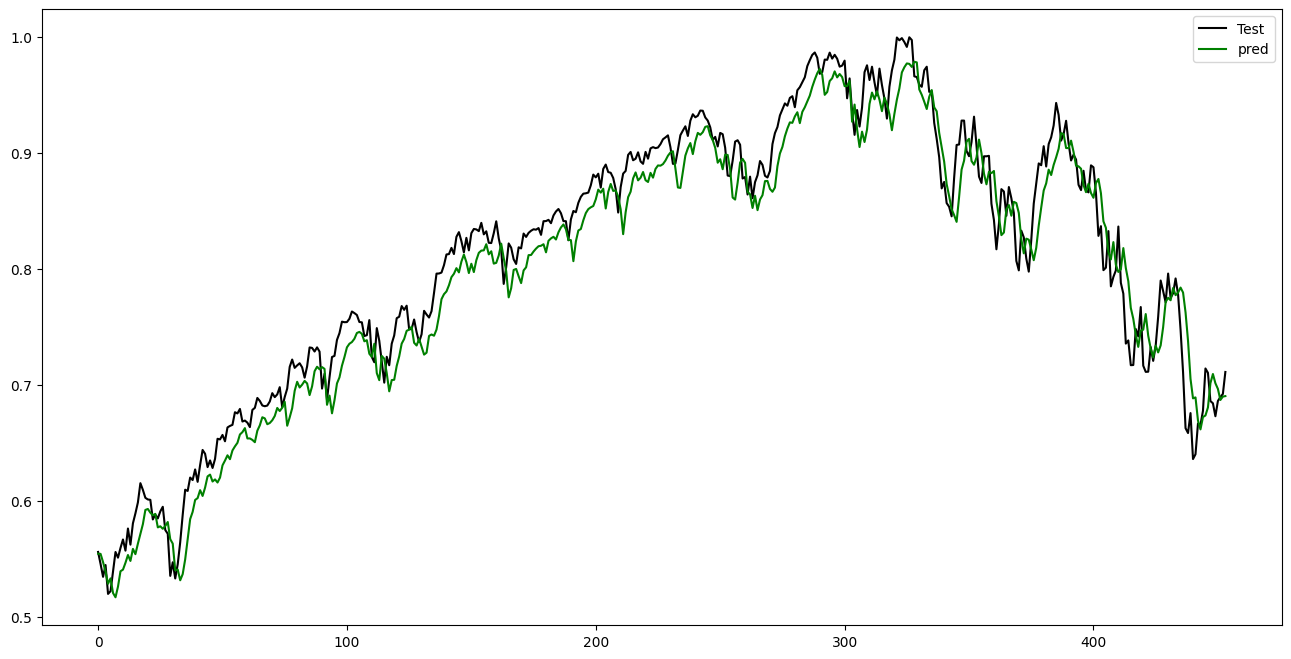

In [57]:
plt.figure(figsize=(16,8))
plt.plot(y_test, color = 'black', label = 'Test')
plt.plot(y_pred, color = 'green', label = 'pred')
plt.legend()
plt.show()